In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import utils.file as futils
import utils.data as datutils
import utils.plots as plots

import warnings
from pandas.errors import ParserWarning
import importlib

warnings.simplefilter(action='ignore', category=ParserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['axes.labelsize'] = 18
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"

In [5]:
mah_dict = futils.get_mah_all()
dsdf = futils.get_ds(snap=125)
smdf = futils.get_morphologies()

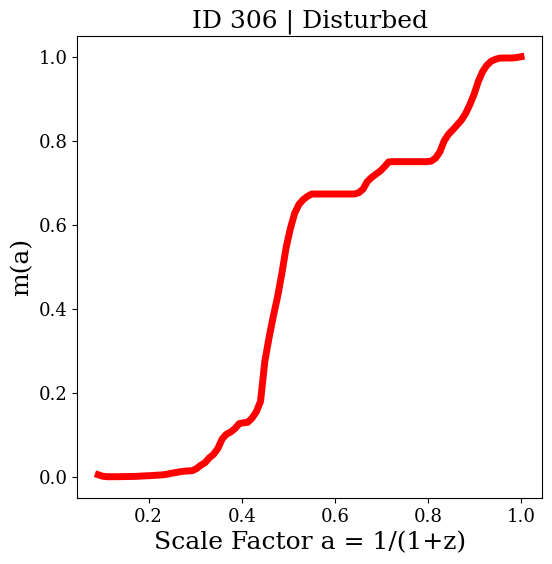

In [6]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(6, 6))
plots.plot_mah(indx=306, axs=axs, am=False)
plt.show()

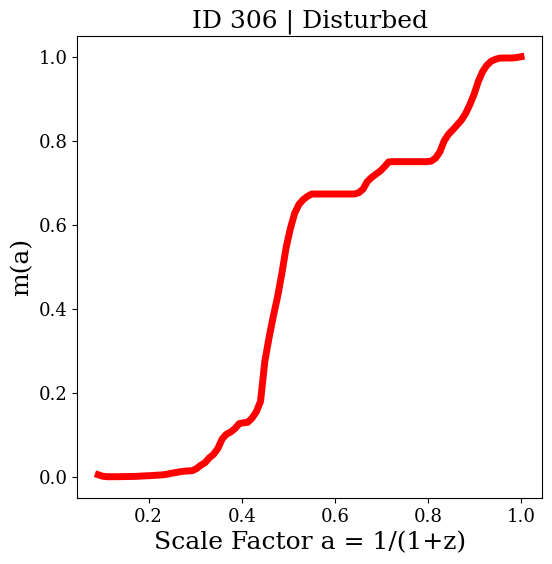

In [7]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(6, 6))
plots.plot_mah(indx=306, axs=axs, am=False)
plt.show()

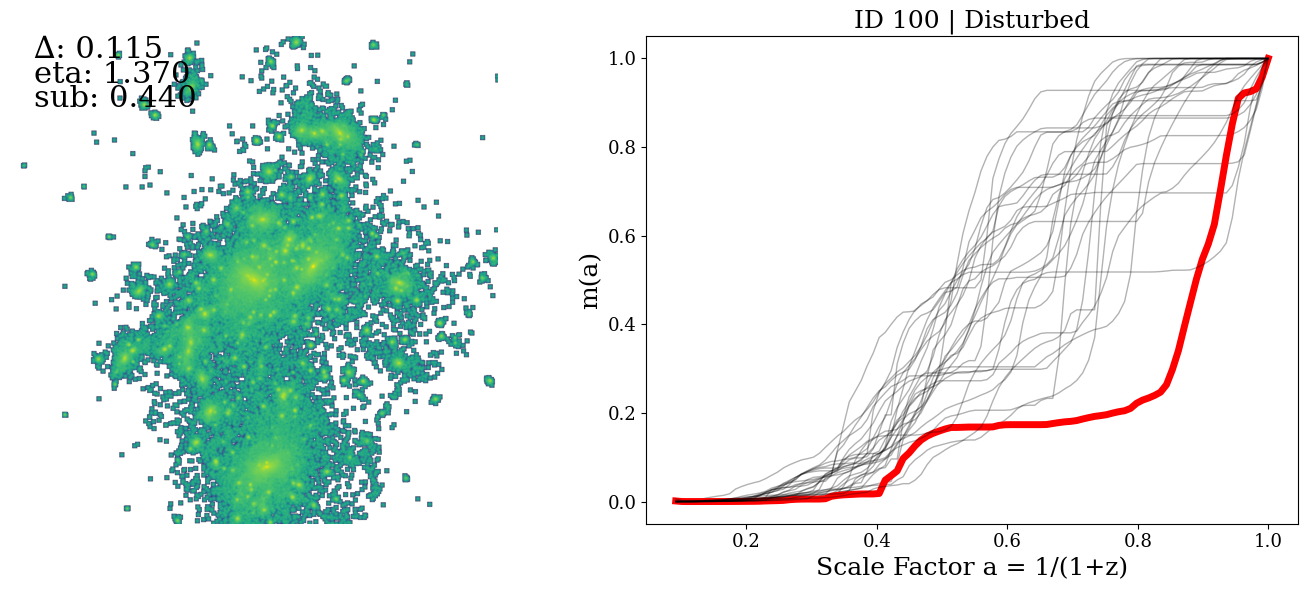

In [8]:
map_dir = 'data/gadgetx3k/maps/zx/'
indx = 100
file = f'bcg_{str(indx).zfill(4)}_125_2.fits'
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
mass_map = futils.load_map(file, map_dir)
plots.display_img(mass_map, axs[0])
axs[0].set_axis_off()
ecom = dsdf.loc[[indx]]['delta_200[4]'].values[0]
evir = dsdf.loc[[indx]]['eta_200[3]'].values[0]
esub = dsdf.loc[[indx]]['fm_200[5]'].values[0]
etxt = f'∆: {ecom:.3f}'
axs[0].annotate(etxt, xy=(0.05, 1.0),
                xycoords='axes fraction', fontsize=22, va='top')
etxt = f'eta: {evir:.3f}'
axs[0].annotate(etxt, xy=(0.05, 0.95),
                xycoords='axes fraction', fontsize=22, va='top')
etxt = f'sub: {esub:.3f}'
axs[0].annotate(etxt, xy=(0.05, 0.90),
                xycoords='axes fraction', fontsize=22, va='top')
plots.plot_mah(indx, axs=axs[1], show_relaxed=True)
plt.tight_layout()
# plt.savefig('plots/late_form.pdf', bbox_inches='tight')
plt.show()

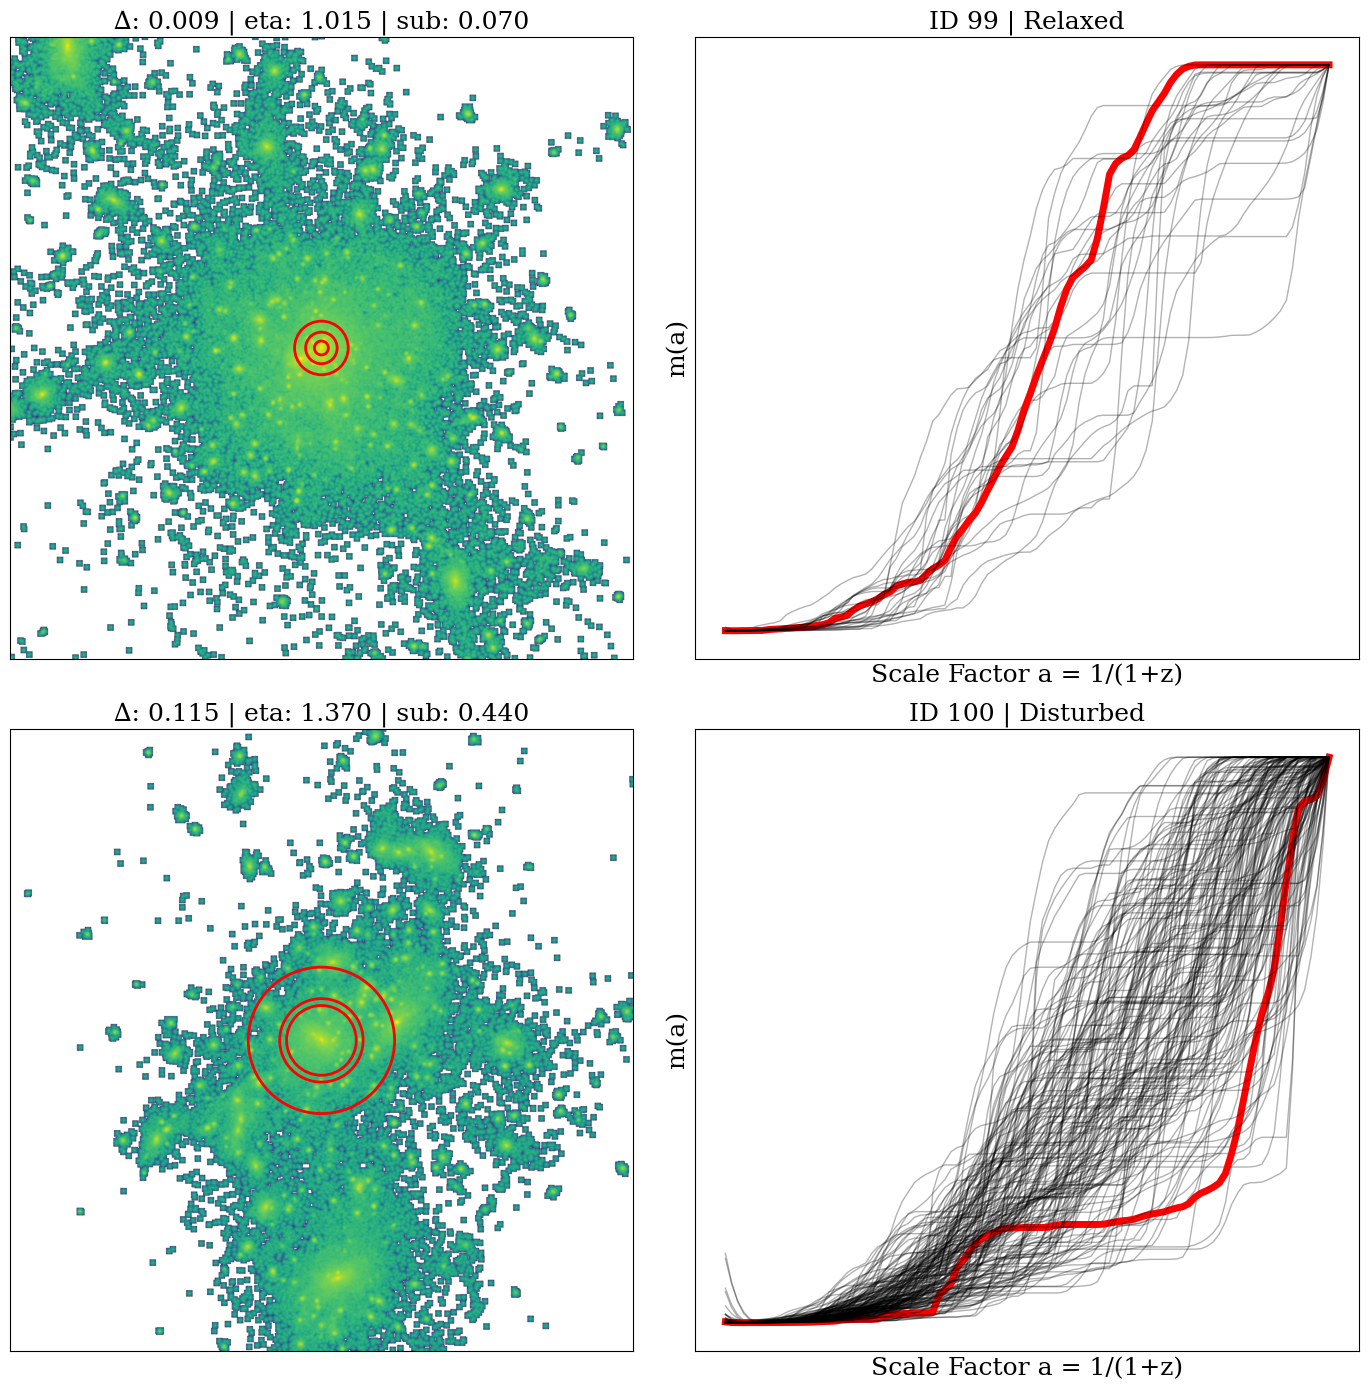

In [9]:
map_dir = 'data/gadgetx3k/maps/zx/'

indx = 99
file = f'bcg_{str(indx).zfill(4)}_125_2.fits'
mass_map = futils.load_map(file, map_dir)

fig, axs = plt.subplots(2, 2, figsize=(14, 14))
for ax_row in axs:
    for ax in ax_row:
        ax.set_xticks([])
        ax.set_yticks([])

ecom = dsdf.loc[[indx]]['delta_200[4]'].values[0]
evir = dsdf.loc[[indx]]['eta_200[3]'].values[0]
esub = dsdf.loc[[indx]]['fm_200[5]'].values[0]
axs[0][0].set_title(f'∆: {ecom:.3f} | eta: {evir:.3f} | sub: {esub:.3f}')
plots.display_img(mass_map, axs[0][0])

rads = smdf.loc[indx][['r20', 'r50', 'r80']].values
center = (mass_map.shape[0] // 2, mass_map.shape[1] // 2)
for r in rads:
    circle = plt.Circle(center, r, color='r', fill=False, lw=2)
    axs[0][0].add_patch(circle)

plots.plot_mah(indx, axs=axs[0][1], show_relaxed=True)

indx = 100
file = f'bcg_{str(indx).zfill(4)}_125_2.fits'
mass_map = futils.load_map(file, map_dir)
plots.display_img(mass_map, axs[1][0])
ecom = dsdf.loc[[indx]]['delta_200[4]'].values[0]
evir = dsdf.loc[[indx]]['eta_200[3]'].values[0]
esub = dsdf.loc[[indx]]['fm_200[5]'].values[0]

axs[1][0].set_title(f'∆: {ecom:.3f} | eta: {evir:.3f} | sub: {esub:.3f}')
rads = smdf.loc[indx][['r20', 'r50', 'r80']].values
center = (mass_map.shape[0] // 2, mass_map.shape[1] // 2)
for r in rads:
    circle = plt.Circle(center, r, color='r', fill=False, lw=2)
    axs[1][0].add_patch(circle)
plots.plot_mah(indx, axs=axs[1][1], show_disturbed=True)

plt.tight_layout()
plt.savefig('plots/maps_mah.pdf')
plt.show()

# AHF Properties

In [ ]:
ahf = futils.get_ahf_all()
for df in ahf.values():
    print(df['Mvir(4)'])

95    2.013060e+10
94    2.314140e+10
93    3.503600e+10
92    4.105760e+10
91    4.359590e+10
          ...     
4     2.253560e+15
3     2.402810e+15
2     2.451690e+15
1     2.516460e+15
0     2.621340e+15
Name: Mvir(4), Length: 96, dtype: float64
105    2.488310e+10
104    3.217380e+10
103    4.026110e+10
102    4.303560e+10
101    4.707930e+10
           ...     
4      2.218640e+15
3      2.248910e+15
2      2.288610e+15
1      2.306750e+15
0      2.295050e+15
Name: Mvir(4), Length: 106, dtype: float64
108    5.714460e+10
107    6.452300e+10
106    7.774770e+10
105    8.781300e+10
104    9.652150e+10
           ...     
4      1.081070e+15
3      1.195650e+15
2      1.320970e+15
1      1.476060e+15
0      1.947270e+15
Name: Mvir(4), Length: 109, dtype: float64
101    2.290510e+10
100    4.731560e+10
99     5.437000e+10
98     5.761720e+10
97     6.594070e+10
           ...     
4      1.582400e+15
3      1.736740e+15
2      1.807230e+15
1      1.920040e+15
0      2.061730e+15
Nam

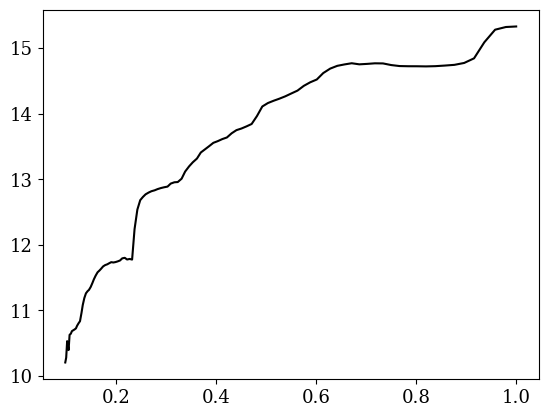

In [39]:
indx = 5
plt.plot(ahf[indx]['aexp'], np.log10(ahf[indx]['Mvir(4)']))

In [ ]:
for i, indx in enumerate(ahf.keys()):
    masses = ahf[indx]['Mvir(4)'].values
    mi = ahf[indx]['Mvir(4)'].values[0]
    mf = ahf[indx]['Mvir(4)'].values[-1]
    plt.hist(np.log10(masses/mf), bins=20)
    plt.show()
    if i ==10: break

In [ ]:
mass_bins = np.linspace(np.log(1e-5), np.log(1.0), num=100)
mass_bins, np.exp(mass_bins)


(array([-11.51292546, -11.39663329, -11.28034111, -11.16404894,
        -11.04775676, -10.93146458, -10.81517241, -10.69888023,
        -10.58258805, -10.46629588, -10.3500037 , -10.23371152,
        -10.11741935, -10.00112717,  -9.884835  ,  -9.76854282,
         -9.65225064,  -9.53595847,  -9.41966629,  -9.30337411,
         -9.18708194,  -9.07078976,  -8.95449758,  -8.83820541,
         -8.72191323,  -8.60562105,  -8.48932888,  -8.3730367 ,
         -8.25674453,  -8.14045235,  -8.02416017,  -7.907868  ,
         -7.79157582,  -7.67528364,  -7.55899147,  -7.44269929,
         -7.32640711,  -7.21011494,  -7.09382276,  -6.97753058,
         -6.86123841,  -6.74494623,  -6.62865406,  -6.51236188,
         -6.3960697 ,  -6.27977753,  -6.16348535,  -6.04719317,
         -5.930901  ,  -5.81460882,  -5.69831664,  -5.58202447,
         -5.46573229,  -5.34944012,  -5.23314794,  -5.11685576,
         -5.00056359,  -4.88427141,  -4.76797923,  -4.65168706,
         -4.53539488,  -4.4191027 ,  -4.

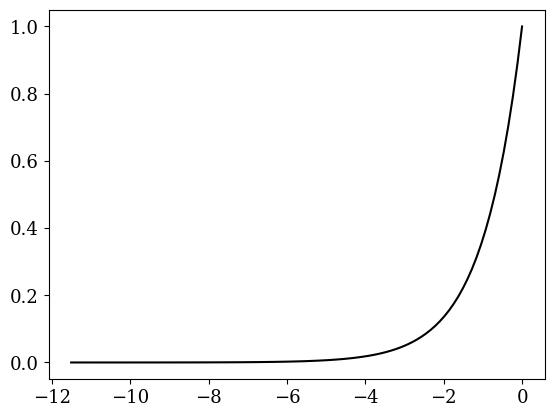

In [37]:
plt.plot(mass_bins, np.exp(mass_bins))